# Customer Churn Analysis and Prediction

## Project Objective

This project analyzes customer churn behavior for a telecom company and develops a machine learning model to identify customers who are likely to leave. The insights will help businesses design effective customer retention strategies.

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Power BI

# Import libraries

In [146]:
# =====================================
# Customer Churn Analysis Project
# Author: Amit Sharma
# =====================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# Chart style
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load dataset

In [147]:
df = pd.read_csv("../data/raw/telcochurn.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [148]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [149]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


# Data Understanding

Before cleaning or modeling the data, we first inspect the dataset to understand its structure, variables, and potential quality issues.

In [150]:
# Display all column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [151]:
df.info() #dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [152]:
df.describe() #Statistical summary

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [153]:
df.describe(include="object") #Categorical summary

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [154]:
# Count missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
                   ..
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Length: 21, dtype: int64

In [155]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Data Cleaning

The dataset appears to have no missing values, but the `TotalCharges` column is stored as text because some rows contain blank spaces instead of numeric values.

We will identify and clean these records before analysis.

In [156]:
# Count blank values in TotalCharges

(df["TotalCharges"] == " ").sum()

np.int64(11)

In [157]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [158]:
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [159]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [161]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
                    ..
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
Length: 21, dtype: int64

The TotalCharges column contained 11 blank values caused by customers with zero tenure. Since these represented only about 0.16% of the dataset, I removed them instead of imputing values to avoid introducing assumptions. The impact on the analysis was negligible.

In [162]:
# Remove rows with missing TotalCharges

df = df.dropna(subset=["TotalCharges"])

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [164]:
df = df.reset_index(drop=True)

# Feature Engineering

This section prepares the dataset for analysis and machine learning by creating new variables and converting existing columns into suitable formats.

In [165]:
# Create target variable

df["ChurnFlag"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

df[["Churn","ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [166]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0:"No",
    1:"Yes"
})

df[["SeniorCitizen","SeniorCitizenLabel"]].head()

,SeniorCitizen,SeniorCitizenLabel
0,0,No
1,0,No
2,0,No
3,0,No
4,0,No


In [167]:
#inspecting every categorical column before doing any visualization.
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("="*50)
    print(column)
    print(df[column].unique())

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']
SeniorCitizenLabel
['No' 'Yes']


In [168]:
for column in categorical_columns:
    df[column] = df[column].str.strip()

In [169]:
for column in categorical_columns:
    print("="*50)
    print(column)
    print(df[column].unique())

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']
SeniorCitizenLabel
['No' 'Yes']


# Exploratory Data Analysis (EDA)

The purpose of this section is to identify the factors that influence customer churn and generate actionable business insights.

In [170]:
# Overall churn distribution

churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [171]:
# Overall churn percentage

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


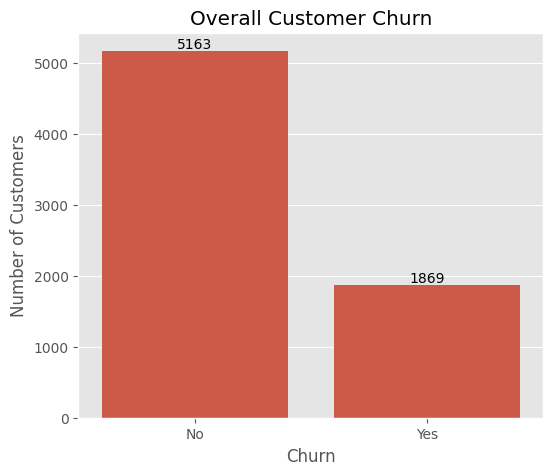

In [172]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Overall Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add labels above bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

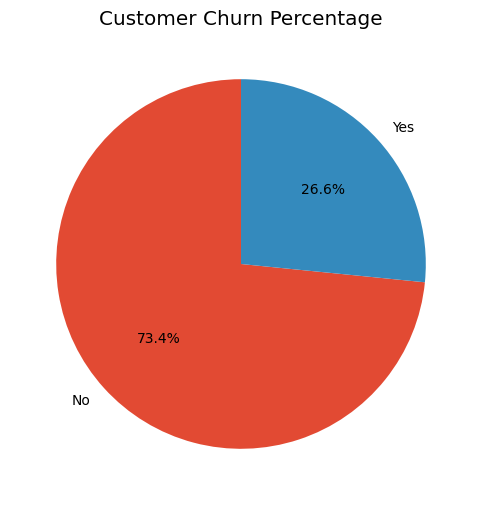

In [173]:
plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

Approximately 73.4% of customers remained with the company, while 26.6% of customers churned. Although the majority of customers are retained, losing more than one-quarter of the customer base represents a significant business challenge. Reducing customer churn should therefore be a strategic priority to improve customer lifetime value and overall revenue

## Churn Analysis by Contract Type

This analysis examines whether the type of customer contract influences the likelihood of churn.

In [174]:
# Churn percentage by contract type

contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: ChurnFlag, dtype: float64

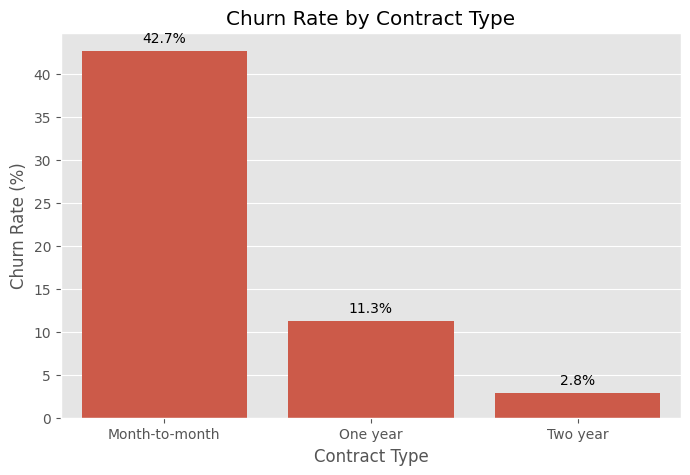

In [175]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(contract_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers on month-to-month contracts have the highest churn rate at 42.7%, compared to 11.3% for one-year contracts and only 2.8% for two-year contracts. This indicates that longer-term contracts are strongly associated with customer retention. The company should focus on encouraging month-to-month customers to upgrade to longer-term plans through targeted incentives or loyalty programs.

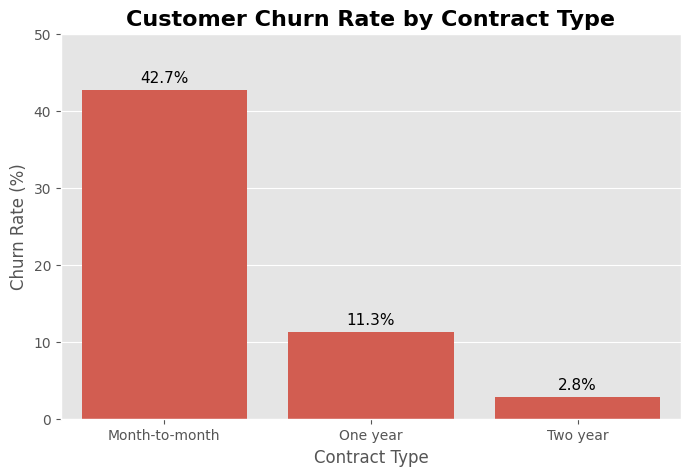

In [176]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values,
    color="#E74C3C"
)

plt.title("Customer Churn Rate by Contract Type", fontsize=16, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(contract_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=11)

plt.ylim(0, 50)

plt.show()

### Tenure Analysis

In [177]:
# Create tenure groups

bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 Months",
    "13-24 Months",
    "25-36 Months",
    "37-48 Months",
    "49-60 Months",
    "61-72 Months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["tenure", "TenureGroup"]].head()

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-36 Months
2,2,0-12 Months
3,45,37-48 Months
4,2,0-12 Months


In [178]:
#Calculate Churn Rate
tenure_churn = (
    df.groupby("TenureGroup")["ChurnFlag"]
      .mean()
      .mul(100)
)

tenure_churn

C:\Users\Amit\AppData\Local\Temp\ipykernel_22520\3180812550.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TenureGroup")["ChurnFlag"]


TenureGroup
0-12 Months     47.678161
13-24 Months    28.710938
25-36 Months    21.634615
37-48 Months    19.028871
49-60 Months    14.423077
61-72 Months     6.609808
Name: ChurnFlag, dtype: float64

In [179]:
df.groupby("TenureGroup", observed=False)["ChurnFlag"]

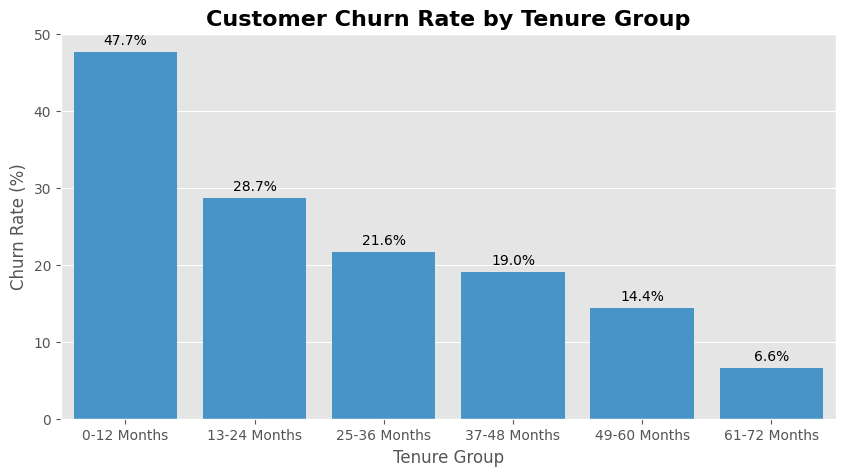

In [180]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values,
    color="#3498DB"
)

plt.title("Customer Churn Rate by Tenure Group", fontsize=16, fontweight="bold")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Customers within their first 12 months have the highest churn rate (47.7%). As customer tenure increases, the churn rate steadily decreases, reaching only 6.6% for customers who have stayed for more than five years. This indicates that customer loyalty strengthens over time, making the first year of the customer lifecycle the most critical period for retention efforts.

### Recommendation

The company should prioritize customer retention during the first 12 months by implementing onboarding programs, personalized support, loyalty rewards, and proactive engagement. Improving the early customer experience is likely to produce the greatest reduction in overall churn.

# High-Risk Customer Segmentation

To support proactive customer retention, we define a simple rule-based high-risk segment.

A customer is classified as **High Risk** if they satisfy **any** of the following:

- Tenure less than 6 months
- Month-to-month contract
- Monthly charges greater than 80

This rule helps identify customers who should be prioritized for retention campaigns.

In [181]:
# High-risk customer segmentation

df["HighRiskSegment"] = np.where(
    (df["tenure"] < 6) |
    (df["Contract"] == "Month-to-month") |
    (df["MonthlyCharges"] > 80),
    "High Risk",
    "Low Risk"
)

df[["tenure", "Contract", "MonthlyCharges", "HighRiskSegment"]].head()

,tenure,Contract,MonthlyCharges,HighRiskSegment
0,1,Month-to-month,29.85,High Risk
1,34,One year,56.95,Low Risk
2,2,Month-to-month,53.85,High Risk
3,45,One year,42.30,Low Risk
4,2,Month-to-month,70.70,High Risk


In [182]:
segment_analysis = (
    df.groupby("HighRiskSegment")
      .agg(
          Customers=("customerID", "count"),
          ChurnRate=("ChurnFlag", "mean")
      )
)

segment_analysis["ChurnRate"] *= 100

segment_analysis

,Customers,ChurnRate
HighRiskSegment,,
High Risk,5116,35.183737
Low Risk,1916,3.601253


In [183]:
baseline_churn = df["ChurnFlag"].mean() * 100

high_risk_churn = (
    segment_analysis.loc["High Risk", "ChurnRate"]
)

lift = high_risk_churn / baseline_churn

print(f"Overall Churn Rate : {baseline_churn:.2f}%")
print(f"High Risk Churn    : {high_risk_churn:.2f}%")
print(f"Lift               : {lift:.2f}x")

Overall Churn Rate : 26.58%
High Risk Churn    : 35.18%
Lift               : 1.32x


The rule-based segmentation successfully identifies a customer group with a churn rate of 35.18%, compared to the overall churn rate of 26.58%. Customers in this segment are 1.32 times more likely to churn, making them the highest priority for retention campaigns.

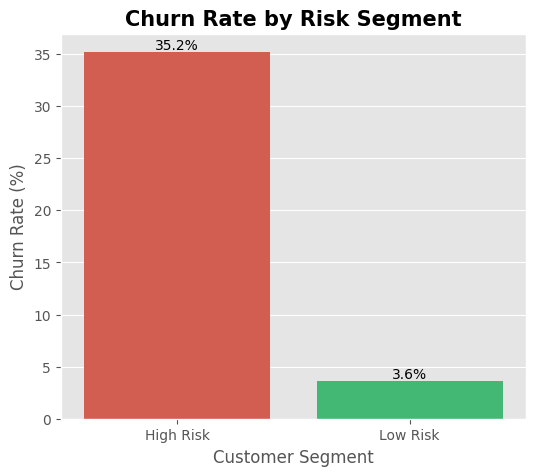

In [184]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=segment_analysis.reset_index(),
    x="HighRiskSegment",
    y="ChurnRate",
    hue="HighRiskSegment",
    palette=["#E74C3C","#2ECC71"],
    legend=False
)

plt.title("Churn Rate by Risk Segment",fontsize=15,fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%")

plt.show()

### Recommendation

The company should proactively target High Risk customers with:

- Loyalty discounts
- Personalized retention offers
- Contract upgrade incentives
- Dedicated customer support
- Early engagement during the first six months

# Monthly Charges Analysis

This analysis investigates whether customers with higher monthly charges are more likely to churn.

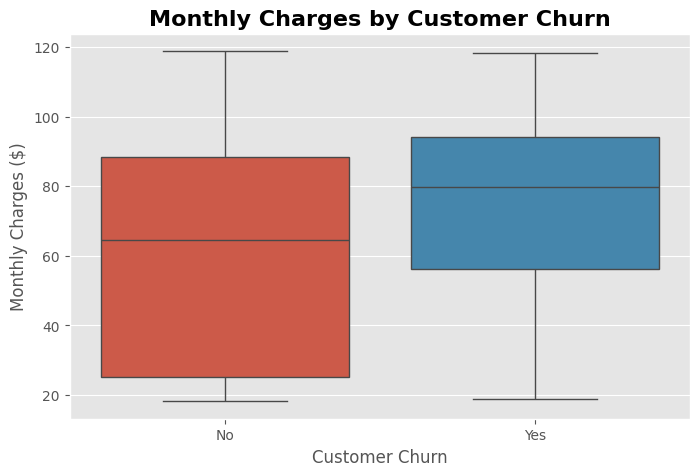

In [185]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    legend=False
)

plt.title("Monthly Charges by Customer Churn", fontsize=16, fontweight="bold")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

In [186]:
monthly_avg = df.groupby("Churn")["MonthlyCharges"].mean()

monthly_avg

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### Business Insight

Customers who churn pay an average monthly charge of **74.44**, compared to **61.31** for retained customers.

The boxplot also shows that churned customers generally have a higher distribution of monthly charges.

Although monthly charges alone do not determine churn, higher pricing appears to be associated with increased customer attrition, particularly when combined with flexible contracts such as Month-to-month.

### Recommendation

The company should review pricing strategies for customers with higher monthly charges.

Offering loyalty discounts, personalized bundles, or contract-based pricing incentives may reduce churn among customers facing higher recurring costs.

# Internet Service Analysis

This analysis examines how customer churn varies across different internet service types.

In [187]:
internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
      .mean() * 100
)

internet_churn = internet_churn.sort_values(ascending=False)

internet_churn

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: ChurnFlag, dtype: float64

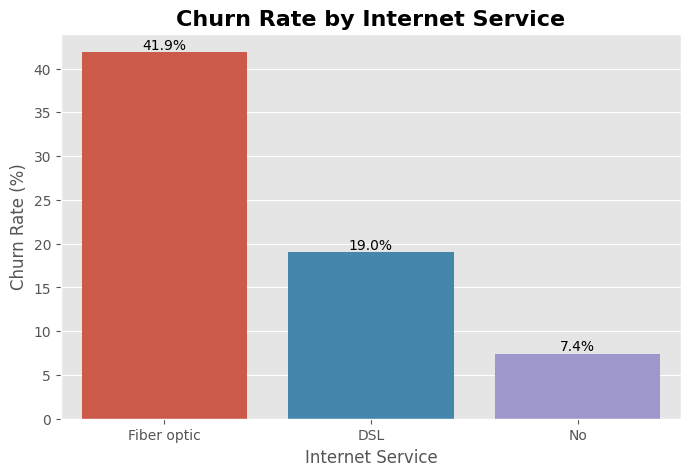

In [188]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values,
    hue=internet_churn.index,
    legend=False
)

plt.title("Churn Rate by Internet Service", fontsize=16, fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Business Insight

Customers using **Fiber optic internet** have the highest churn rate (**41.9%**), more than double that of DSL customers (**19.0%**) and significantly higher than customers without internet service (**7.4%**).

This suggests that Fiber optic customers represent a critical segment for retention initiatives. Additional investigation into pricing, service quality, and customer satisfaction is recommended.

### Recommendation

The company should prioritize Fiber optic customers for retention campaigns by:

- Monitoring service quality
- Reviewing pricing competitiveness
- Offering loyalty discounts
- Providing proactive technical support
- Collecting customer feedback before contract renewal

# Payment Method Analysis

This analysis examines customer churn across different payment methods to identify payment behaviors associated with higher churn.

In [189]:
payment_churn = (
    (df.groupby("PaymentMethod")["ChurnFlag"].mean() * 100)
    .sort_values(ascending=False)
)

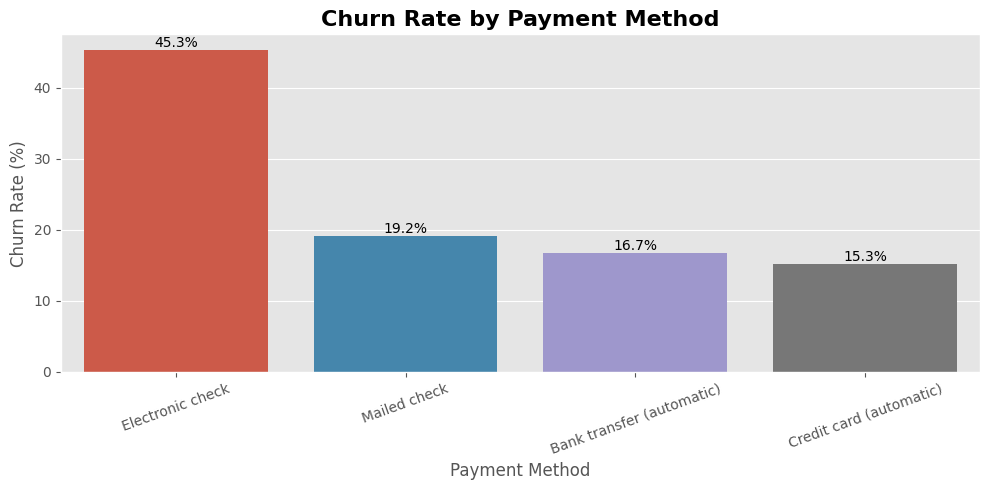

In [190]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values,
    hue=payment_churn.index,
    legend=False
)

plt.title("Churn Rate by Payment Method", fontsize=16, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

In [191]:
payment_summary = (
    df.groupby("PaymentMethod")
      .agg(
          Customers=("customerID", "count"),
          ChurnRate=("ChurnFlag", "mean")
      )
)

payment_summary["ChurnRate"] *= 100

payment_summary.sort_values("ChurnRate", ascending=False)

,Customers,ChurnRate
PaymentMethod,,
Electronic check,2365,45.285412
Mailed check,1604,19.201995
Bank transfer (automatic),1542,16.731518
Credit card (automatic),1521,15.253123


### Tech Support Analysis
This analysis examines whether access to technical support affects customer churn.


In [192]:
tech_churn = (
    df.groupby("TechSupport")["ChurnFlag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

tech_churn

TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: ChurnFlag, dtype: float64

In [193]:
tech_summary = (
    df.groupby("TechSupport")
      .agg(
          Customers=("customerID","count"),
          ChurnRate=("ChurnFlag","mean")
      )
)

tech_summary["ChurnRate"] *= 100

tech_summary.sort_values("ChurnRate", ascending=False)

,Customers,ChurnRate
TechSupport,,
No,3472,41.647465
Yes,2040,15.196078
No internet service,1520,7.434211


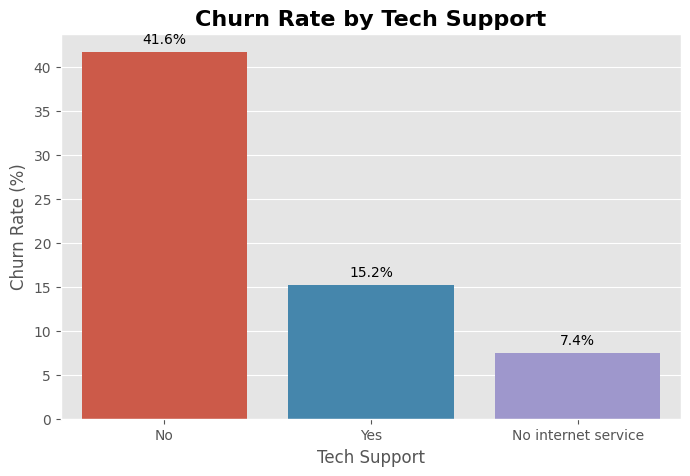

In [194]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=tech_churn.index,
    y=tech_churn.values,
    hue=tech_churn.index,
    legend=False
)

plt.title("Churn Rate by Tech Support", fontsize=16, fontweight="bold")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tech_churn.values):
    plt.text(i, value+1, f"{value:.1f}%", ha="center")

plt.show()

### Observation

Customers without Tech Support experience the highest churn rate (41.6%), while customers who receive Tech Support have a much lower churn rate (15.2%).

Customers with no internet service exhibit the lowest churn because they do not require technical assistance.

This suggests that providing reliable technical support significantly improves customer retention.

### Business Recommendation

• Promote Tech Support plans during customer onboarding.

• Offer discounted Tech Support for customers identified as high-risk.

• Provide proactive technical assistance before customers experience recurring issues.

Improving access to technical support can substantially reduce customer churn and improve customer satisfaction.

## Online Security Analysis

This analysis evaluates whether customers who subscribe to the Online Security service are less likely to churn.

In [195]:
security_churn = (
    df.groupby("OnlineSecurity")["ChurnFlag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

security_churn

OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: ChurnFlag, dtype: float64

In [196]:
security_summary = (
    df.groupby("OnlineSecurity")
      .agg(
          Customers=("customerID", "count"),
          ChurnRate=("ChurnFlag", "mean")
      )
)

security_summary["ChurnRate"] *= 100

security_summary.sort_values("ChurnRate", ascending=False)

,Customers,ChurnRate
OnlineSecurity,,
No,3497,41.778667
Yes,2015,14.640199
No internet service,1520,7.434211


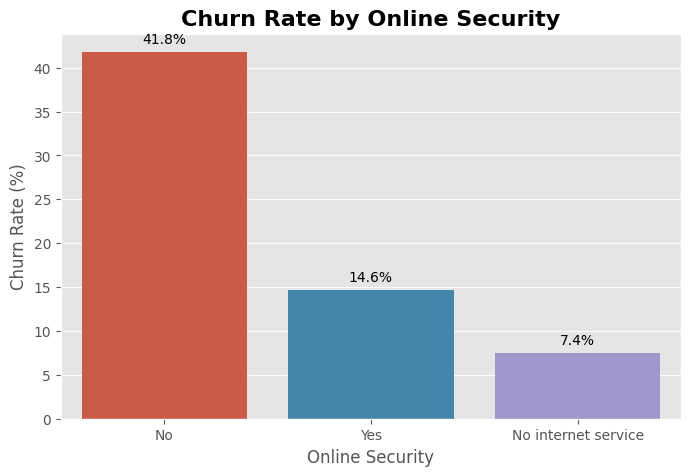

In [197]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=security_churn.index,
    y=security_churn.values,
    hue=security_churn.index,
    legend=False
)

plt.title("Churn Rate by Online Security",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(security_churn.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

### Observation

Customers without Online Security have the highest churn rate, whereas customers who subscribe to Online Security have a significantly lower churn rate.

Customers with no internet service exhibit the lowest churn because Online Security is not applicable to them.

This indicates that Online Security is strongly associated with customer retention.

### Business Recommendation

- Promote Online Security as part of internet service packages.
- Offer discounted security plans to high-risk customers.
- Bundle Online Security with long-term contracts to improve customer retention.
- Highlight the value of secure internet access during customer onboarding.

## Contract Type and Internet Service Analysis

This analysis investigates how churn varies across different combinations of contract types and internet services to identify the highest-risk customer segments.

In [198]:
contract_internet = (
    df.groupby(["Contract", "InternetService"])["ChurnFlag"]
      .mean()
      .mul(100)
      .reset_index()
)

contract_internet

,Contract,InternetService,ChurnFlag
0,Month-to-month,DSL,32.215863
1,Month-to-month,Fiber optic,54.605263
2,Month-to-month,No,18.893130
3,One year,DSL,9.298246
4,One year,Fiber optic,19.294991
5,One year,No,2.479339
6,Two year,DSL,1.926164
7,Two year,Fiber optic,7.226107
8,Two year,No,0.789889


In [199]:
contract_summary = (
    df.groupby(["Contract", "InternetService"])
      .agg(
          Customers=("customerID", "count"),
          ChurnRate=("ChurnFlag", "mean")
      )
      .reset_index()
)

contract_summary["ChurnRate"] *= 100

contract_summary.sort_values("ChurnRate", ascending=False)

,Contract,InternetService,Customers,ChurnRate
1,Month-to-month,Fiber optic,2128,54.605263
0,Month-to-month,DSL,1223,32.215863
4,One year,Fiber optic,539,19.294991
2,Month-to-month,No,524,18.893130
3,One year,DSL,570,9.298246
7,Two year,Fiber optic,429,7.226107
5,One year,No,363,2.479339
6,Two year,DSL,623,1.926164
8,Two year,No,633,0.789889


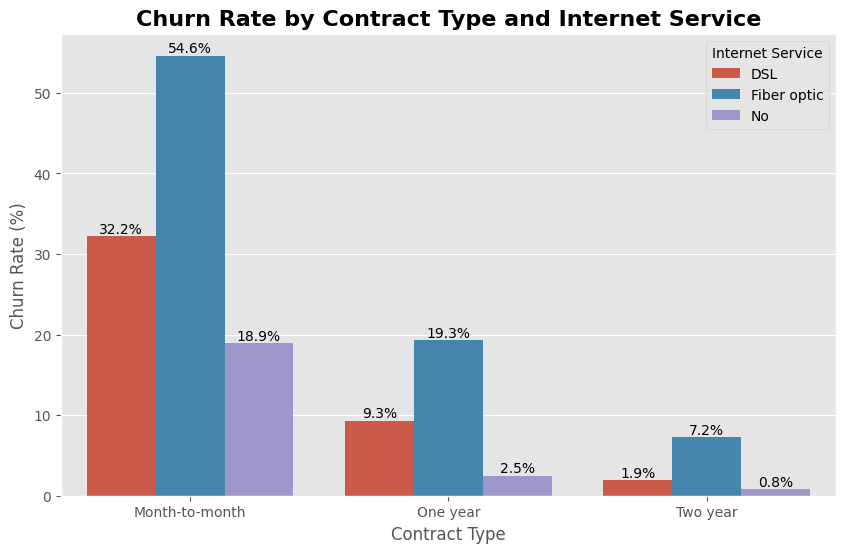

In [200]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=contract_summary,
    x="Contract",
    y="ChurnRate",
    hue="InternetService"
)

plt.title("Churn Rate by Contract Type and Internet Service",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.legend(title="Internet Service")

plt.show()

### Observation

Customers using Fiber Optic internet with Month-to-Month contracts exhibit the highest churn rate.

Conversely, customers on One-Year and Two-Year contracts show substantially lower churn regardless of internet service type.

Long-term contracts appear to reduce churn even among customers with premium internet services.

### Business Recommendation

• Encourage Fiber Optic customers to migrate from Month-to-Month to long-term contracts.

• Provide renewal discounts and loyalty benefits for Fiber Optic users.

• Target Month-to-Month Fiber Optic customers with personalized retention campaigns.

• Bundle premium internet services with value-added offerings such as Online Security and Tech Support.

## Correlation Analysis

To better understand the relationships between customer attributes and churn, categorical variables are temporarily encoded into numerical values. This encoding is performed solely for exploratory analysis and should not be confused with the machine learning preprocessing used in the next notebook.

In [201]:
# Create a copy so the original EDA dataset remains unchanged
corr_df = df.copy()

In [202]:
# Encode target variable

corr_df["Churn"] = corr_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [203]:
# Remove customer identifier

corr_df = corr_df.drop(columns=["customerID"])

In [204]:
# Encode binary categorical variables

corr_df["gender"] = corr_df["gender"].map({
    "Male": 1,
    "Female": 0
})

binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    corr_df[col] = corr_df[col].map({
        "Yes": 1,
        "No": 0
    })

In [205]:
# One-Hot Encode remaining categorical variables

multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

corr_df = pd.get_dummies(
    corr_df,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

# Correlation Analysis

This section explores the relationship between numerical features and customer churn before building machine learning models.

In [206]:
# Compute correlation matrix

correlation = corr_df.corr(numeric_only=True)

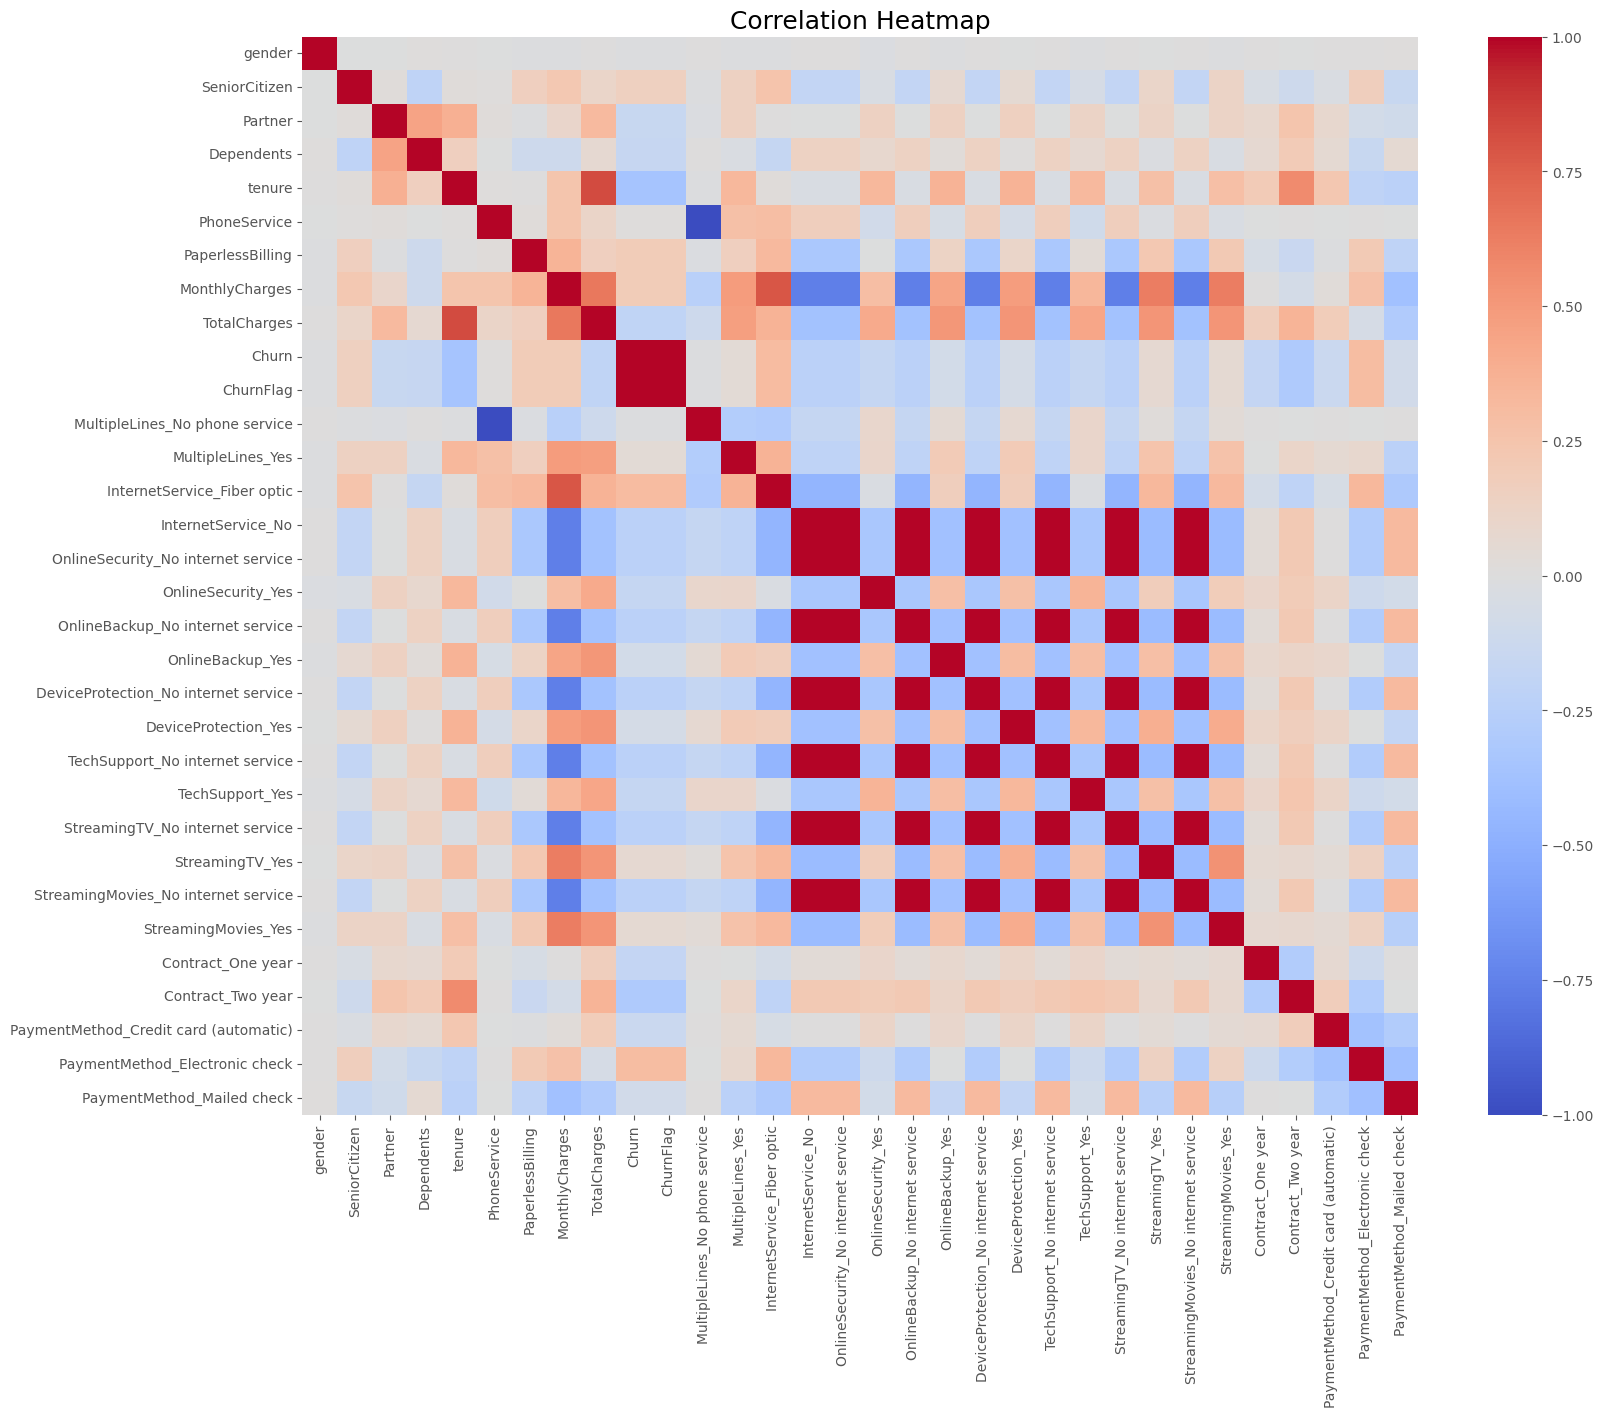

In [207]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

In [208]:
# Correlation of all features with Churn

churn_corr = correlation["Churn"].sort_values(ascending=False)

churn_corr

ChurnFlag                               1.000000
Churn                                   1.000000
InternetService_Fiber optic             0.307463
PaymentMethod_Electronic check          0.301455
MonthlyCharges                          0.192858
                                          ...   
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, Length: 32, dtype: float64

In [209]:
# Top Positive Correlations with Churn

top_positive = churn_corr.head(10)

top_positive

ChurnFlag                         1.000000
Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
Name: Churn, dtype: float64

In [210]:
# Top Negative Correlations with Churn

top_negative = churn_corr.tail(10)

top_negative

TotalCharges                           -0.199484
InternetService_No                     -0.227578
StreamingTV_No internet service        -0.227578
OnlineSecurity_No internet service     -0.227578
OnlineBackup_No internet service       -0.227578
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64

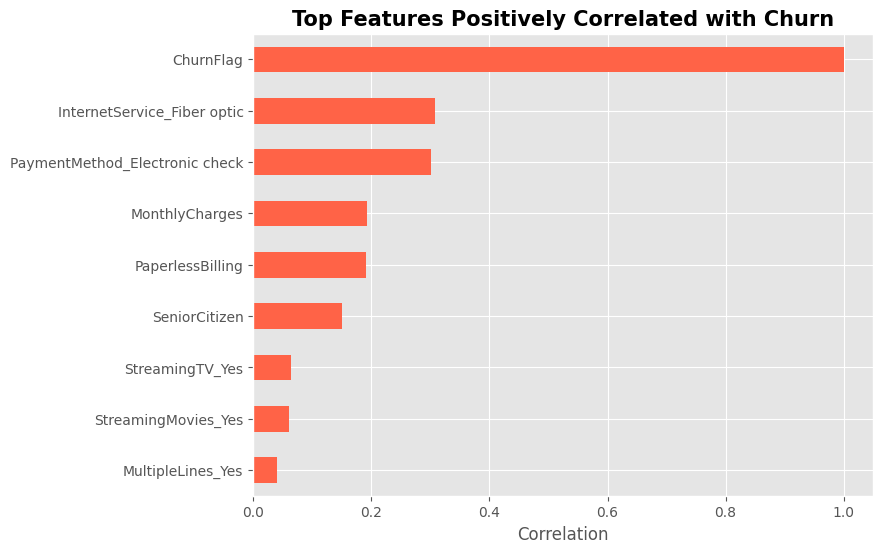

In [211]:
plt.figure(figsize=(8,6))

top_positive.drop("Churn").sort_values().plot(
    kind="barh",
    color="tomato"
)

plt.title("Top Features Positively Correlated with Churn",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Correlation")

plt.show()

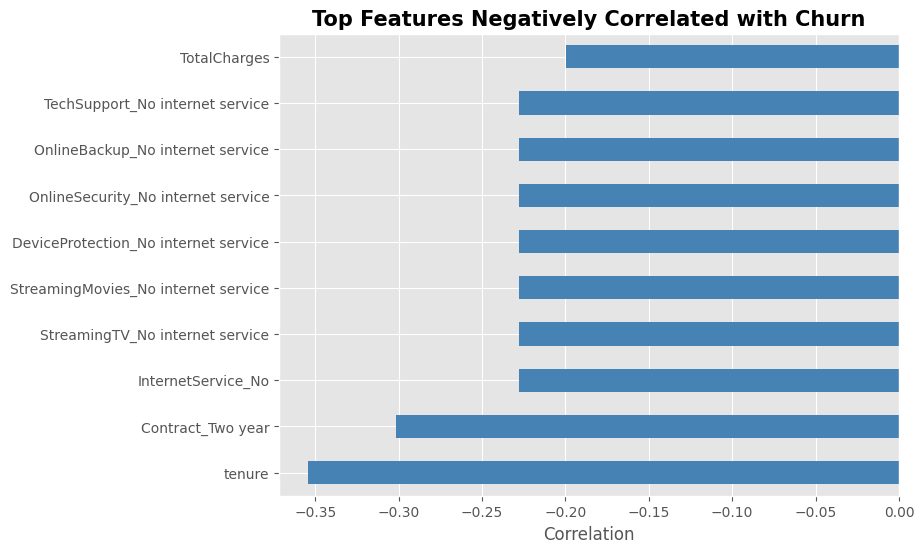

In [212]:
plt.figure(figsize=(8,6))

top_negative.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top Features Negatively Correlated with Churn",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Correlation")

plt.show()

## Correlation Analysis Insights

### Positive Correlations with Churn

- Fiber Optic internet service has the strongest positive correlation with churn.
- Customers using Electronic Check payments are more likely to churn.
- Higher Monthly Charges are associated with increased churn.
- Paperless Billing shows a mild positive relationship with churn.

### Negative Correlations with Churn

- Longer customer tenure significantly reduces churn.
- Two-Year contracts exhibit the strongest negative correlation with churn.
- One-Year contracts also contribute to better customer retention.
- Customers using Tech Support and Online Security services are less likely to churn.

### Business Insight

Customer retention is strongly influenced by contract duration, service quality, and customer tenure.

### Recommendation

The company should prioritize retention campaigns for:

- Customers within their first year.
- Month-to-month contract customers.
- Fiber Optic subscribers.
- Electronic Check users.
- Customers without Tech Support or Online Security.

# Export Clean Dataset

The cleaned business dataset is exported for Power BI dashboard creation. No machine learning preprocessing is applied to this dataset.

In [213]:
# Save cleaned dataset for Power BI

df.to_csv(
    "../data/processed/telco_churn_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!
